In [9]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import arviz as az
from pathlib import Path

BASE_DIR = Path.cwd().parent
RESULTS_DIR = BASE_DIR / "results"
TRACE_DIR = BASE_DIR / "results/trace"
PPC_DIR = BASE_DIR / "results/ppc"

os.makedirs(RESULTS_DIR / "plots/", exist_ok=True)

In [16]:
with open(TRACE_DIR / "final_trace_owner.pkl", "rb") as f:
    fin_tr_owner = pickle.load(f)
    
with open(TRACE_DIR / "final_trace_agent.pkl", "rb") as f:
    fin_tr_agent = pickle.load(f)

In [17]:
log_z_owner = fin_tr_owner.sample_stats.log_marginal_likelihood.mean().item()
log_z_agent = fin_tr_agent.sample_stats.log_marginal_likelihood.mean().item()

# 3. Bayes Factor Computation
log_BF = log_z_agent - log_z_owner
BF = np.exp(log_BF)

print("\n--- BATCH RESULTS ---")
print(f"Log Z (Owner Model): {log_z_owner:.4f}")
print(f"Log Z (Agent Model): {log_z_agent:.4f}")
print(f"Bayes Factor:  {BF:.4e}")

if BF > 1000:
    print("Conclusion: Decisive Evidence for the AGENT model.")
elif BF > 10:
    print("Conclusion: Strong Evidence for the AGENT model.")
elif BF > 1:
    print("Conclusion: Moderate Evidence for the AGENT model.")
elif BF > 0.1:
    print("Conclusion: Moderate Evidence for the OWNER model.")
elif BF > 0.01:
    print("Conclusion: Strong Evidence for the OWNER model.")
else:
    print("Conclusion: Decisive Evidence for the OWNER model.")


--- BATCH RESULTS ---
Log Z (Owner Model): -4.7076
Log Z (Agent Model): -2.2944
Bayes Factor:  1.1169e+01
Conclusion: Strong Evidence for the AGENT model.


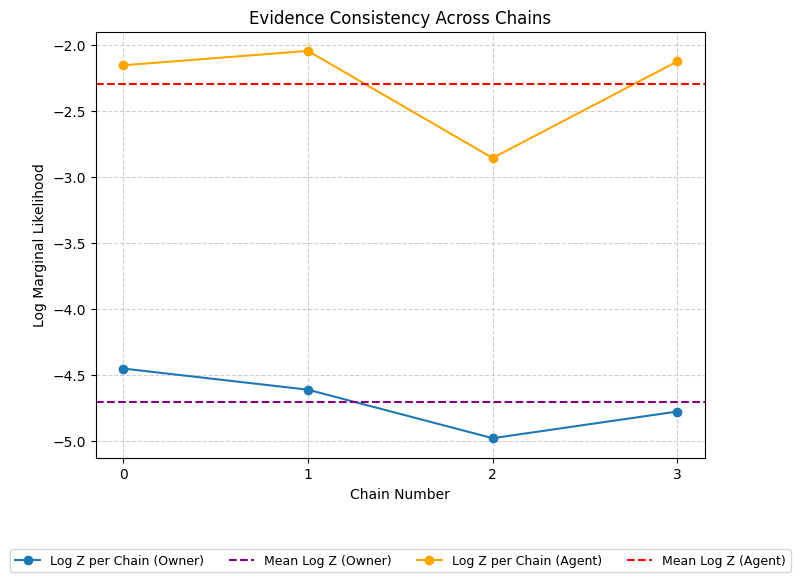

In [24]:
# Access the log_marginal_likelihood per chain
# This shows if all chains reached roughly the same conclusion
log_z_per_chain_owner = fin_tr_owner.sample_stats.log_marginal_likelihood.values[:,-1]
log_z_per_chain_agent = fin_tr_agent.sample_stats.log_marginal_likelihood.values[:,-1]

plt.figure(figsize=(8, 6))
plt.plot(log_z_per_chain_owner, 'o-', label='Log Z per Chain (Owner)')
plt.axhline(log_z_per_chain_owner.mean(), color='purple', linestyle='--', label='Mean Log Z (Owner)')
plt.plot(log_z_per_chain_agent, 'o-', color='orange', label='Log Z per Chain (Agent)')
plt.axhline(log_z_per_chain_agent.mean(), color='r', linestyle='--', label='Mean Log Z (Agent)')

plt.xlabel('Chain Number')
plt.ylabel('Log Marginal Likelihood')
plt.title('Evidence Consistency Across Chains')
plt.xticks([0, 1, 2, 3])
plt.grid(True, linestyle='--', alpha=0.6)

# Move legend below the plot, center it, and set to 4 columns
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fontsize=9, ncol=4, frameon=True)

# Use tight_layout or subplots_adjust to ensure the legend isn't cut off
plt.tight_layout() 
plt.show()

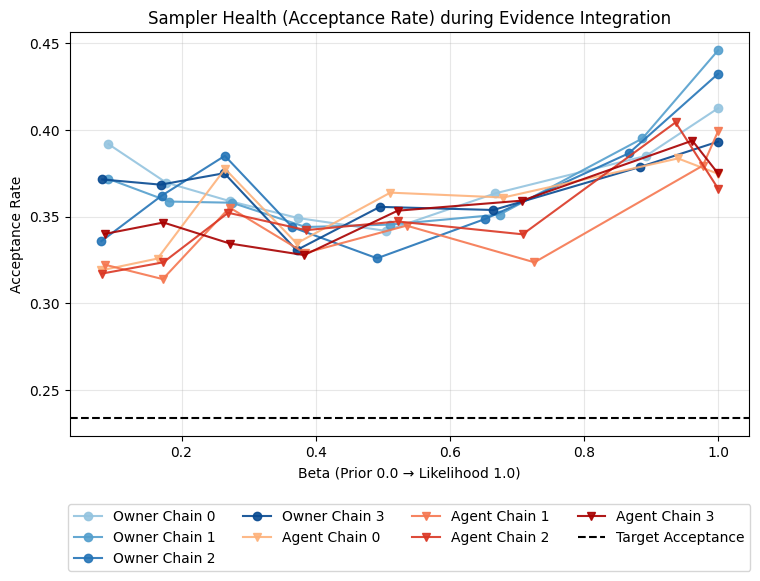

In [19]:
# Accessing the available variables from your KeyError list
accept_rates_owner = fin_tr_owner.sample_stats["accept_rate"].values
betas_owner = fin_tr_owner.sample_stats["beta"].values
accept_rates_agent = fin_tr_agent.sample_stats["accept_rate"].values
betas_agent = fin_tr_agent.sample_stats["beta"].values

plt.figure(figsize=(8, 6))

# Create color gradients
owner_colors = plt.cm.Blues(np.linspace(0.4, 0.9, accept_rates_owner.shape[0]))
agent_colors = plt.cm.OrRd(np.linspace(0.4, 0.9, accept_rates_agent.shape[0]))

# Owner chains (blue shades)
for i in range(accept_rates_owner.shape[0]):
    plt.plot(
        betas_owner[i],
        accept_rates_owner[i],
        'o-',
        color=owner_colors[i],
        alpha=0.9,
        label=f'Owner Chain {i}'
    )

# Agent chains (orange/red shades)
for i in range(accept_rates_agent.shape[0]):
    plt.plot(
        betas_agent[i],
        accept_rates_agent[i],
        'v-',
        color=agent_colors[i],
        alpha=0.9,
        label=f'Agent Chain {i}'
    )

plt.axhline(y=0.234, color='k', linestyle='--', label='Target Acceptance')
plt.xlabel('Beta (Prior 0.0 → Likelihood 1.0)')
plt.ylabel('Acceptance Rate')
plt.title('Sampler Health (Acceptance Rate) during Evidence Integration')
plt.grid(True, alpha=0.3)
plt.legend(
    loc='upper center', 
    bbox_to_anchor=(0.5, -0.15), 
    ncol=4, 
    frameon=True
)
plt.tight_layout()
plt.show()

In [20]:
with open(PPC_DIR / "ppc_owner.pkl", "rb") as f:
    ppc_owner = pickle.load(f)
    
with open(PPC_DIR / "ppc_agent.pkl", "rb") as f:
    ppc_agent = pickle.load(f)

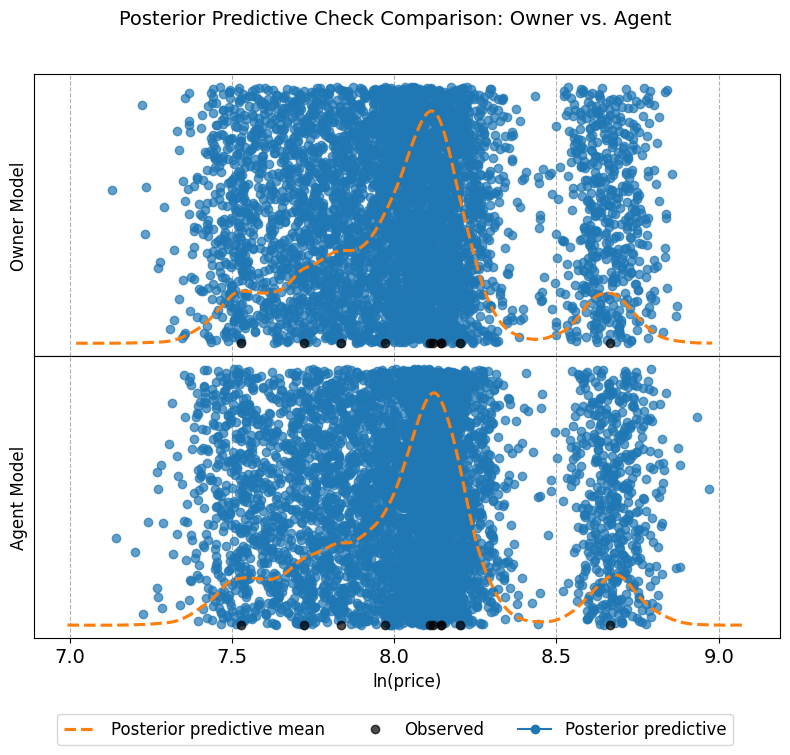

In [32]:
# Create subplots with shared x-axis
fig, (ax_owner, ax_agent) = plt.subplots(nrows=2, ncols=1, figsize=(8, 8), sharex=True)

# Plot Owner Model PPC (Top)
az.plot_ppc(ppc_owner, kind="scatter", num_pp_samples=500, ax=ax_owner, legend=False)
ax_owner.set_ylabel("Owner Model", fontsize=12)
ax_owner.grid(True, linestyle='--', alpha=1)

# Plot Agent Model PPC (Bottom)
az.plot_ppc(ppc_agent, kind="scatter", num_pp_samples=500, ax=ax_agent, legend=False)
ax_agent.set_ylabel("Agent Model", fontsize=12)
ax_agent.grid(True, linestyle='--', alpha=1)

# Set main title
fig.suptitle("Posterior Predictive Check Comparison: Owner vs. Agent", fontsize=14, y=0.95)

# Add X-axis label to bottom plot
ax_agent.set_xlabel("ln(price)", fontsize=12)

# Create the shared 3-column legend
handles, labels = ax_owner.get_legend_handles_labels()
fig.legend(
    handles, 
    labels, 
    fontsize=12,
    loc='lower center', 
    bbox_to_anchor=(0.5, 0.02), 
    ncol=3, 
    frameon=True
)

# CRITICAL STEP: Adjust layout first, THEN remove hspace
plt.tight_layout(rect=[0, 0.08, 1, 0.93])
plt.subplots_adjust(hspace=0) 

plt.show()